In [1]:
from pyspark.sql import SparkSession

# 1. Aseguramos la sesión activa en el Kernel actual
spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

# 2. Traemos los datos nativos persistidos en formato Parquet
# Apuntamos a la carpeta real de datos etiquetados que tienes en tu directorio
ruta_datos_retail = "/home/jovyan/work/notebooks/modelos_output/datos_etiquetados_kmeans"

# Cargamos el DataFrame con los datos de tu clúster de Retail
df_completos = spark.read.parquet(ruta_datos_retail)
df_historico = spark.read.parquet(ruta_datos_retail)

# 3. Contamos cuántos registros totales logramos recuperar para el análisis
total_registros = df_historico.count()
print(f"ÉXITO: Conexión establecida. Hemos recuperado {total_registros} registros de retail del histórico.")

ÉXITO: Conexión establecida. Hemos recuperado 6174 registros de retail del histórico.


In [2]:
import pyspark.sql.functions as F

# 1. Calculamos el total de SKUs usando los datos etiquetados de retail alimenticio
total_sku = df_historico.count()

# 2. Agrupamos por marca para determinar su peso en la canasta básica
kpi_estrategico = df_historico.groupBy("marca") \
    .agg(
        F.count("marca").alias("Cantidad_SKUs"),
        F.round((F.count("marca") / total_sku) * 100, 2).alias("Participacion_Catalogo_Porcentaje")
    ).orderBy(F.desc("Cantidad_SKUs"))

# 3. Desplegamos el indicador clave de estructura de portafolio
print("=========================================================================")
print("[KPI ESTRATÉGICO] - ESTRUCTURA DE PORTAFOLIO DE MARCAS (RETAIL ALIMENTICIO)")
print("=========================================================================")

kpi_estrategico.show(20, truncate=False)

[KPI ESTRATÉGICO] - ESTRUCTURA DE PORTAFOLIO DE MARCAS (RETAIL ALIMENTICIO)
+--------------+-------------+---------------------------------+
|marca         |Cantidad_SKUs|Participacion_Catalogo_Porcentaje|
+--------------+-------------+---------------------------------+
|GENÉRICA      |1051         |17.02                            |
|LIDER         |298          |4.83                             |
|OTRA          |274          |4.44                             |
|Cuisine & Co  |274          |4.44                             |
|NUESTRA COCINA|172          |2.79                             |
|Soprole       |160          |2.59                             |
|GOURMET       |151          |2.45                             |
|Gourmet       |147          |2.38                             |
|COLUN         |125          |2.02                             |
|SOPROLE       |119          |1.93                             |
|Colun         |83           |1.34                             |
|MAGGI        

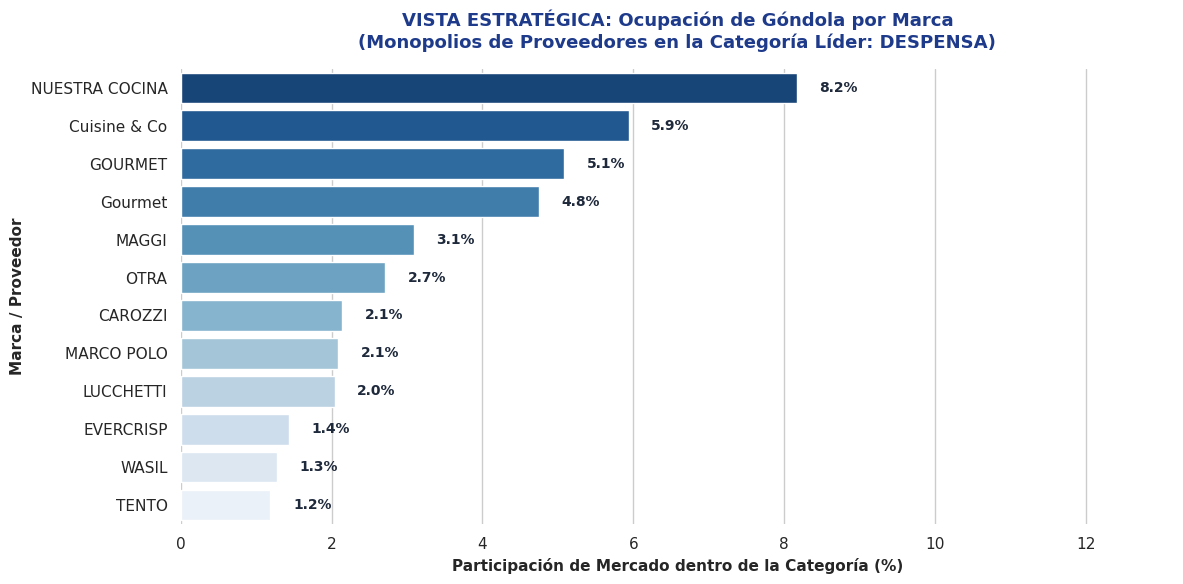

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# =========================================================================
# 1. PROCESAMIENTO EN SPARK: DETECCIÓN DE CONCENTRACIÓN EN CATEGORÍA LÍDER
# =========================================================================

# Identificamos de manera dinámica la categoría más demandada (con mayor stock en góndola)
categoria_lider = df_historico.groupBy("categoria") \
    .count() \
    .orderBy(F.desc("count")) \
    .first()["categoria"]

# Contamos el total de productos (SKUs) pertenecientes a esa categoría líder
total_sku_lider = df_historico.filter(F.col("categoria") == categoria_lider).count()

# Calculamos el peso y participación de cada marca únicamente dentro de esta categoría principal
kpi_estrategico = df_historico.filter(F.col("categoria") == categoria_lider) \
    .groupBy("marca") \
    .agg(
        F.count("marca").alias("Cantidad_SKUs"),
        F.round((F.count("marca") / total_sku_lider) * 100, 2).alias("Participacion_Porcentaje")
    ).orderBy(F.desc("Cantidad_SKUs"))

# =========================================================================
# 2. CONVERSIÓN Y DISEÑO DEL GRÁFICO (Top 12 marcas de la categoría líder)
# =========================================================================
df_est_pandas = kpi_estrategico.toPandas().head(12)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Generamos un gráfico moderno de barras horizontales libre de advertencias
ax = sns.barplot(
    x="Participacion_Porcentaje",
    y="marca",
    data=df_est_pandas,
    hue="marca",
    palette="Blues_r",  # Gradiente azul corporativo muy sobrio
    legend=False
)

# Colocamos las etiquetas numéricas de porcentaje de manera limpia
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.1f}%",
            (width + 0.3, p.get_y() + p.get_height() / 2),
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
            color="#1e293b"
        )

# Títulos adaptados a tu análisis estratégico
plt.title(
    f"VISTA ESTRATÉGICA: Ocupación de Góndola por Marca\n"
    f"(Monopolios de Proveedores en la Categoría Líder: {categoria_lider.upper()})",
    fontsize=13,
    fontweight="bold",
    pad=15,
    color="#1e3a8a"
)
plt.xlabel("Participación de Mercado dentro de la Categoría (%)", fontsize=11, fontweight="bold")
plt.ylabel("Marca / Proveedor", fontsize=11, fontweight="bold")

# Margen extendido para evitar cortes en el gráfico
plt.xlim(0, df_est_pandas["Participacion_Porcentaje"].max() + 5)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [4]:
import pyspark.sql.functions as F

# 1. Filtramos los productos de la Gama Media (Clúster 1) que es donde se concentra la competencia real
df_gama_media = df_historico.filter(F.col("prediction") == 1)

# 2. Analizamos las bandas de precios reales por Supermercado dentro de este segmento clave
kpi_tactico = df_gama_media.groupBy("supermercado") \
    .agg(
        F.round(F.min("precio"), 2).alias("Precio_Minimo"),
        F.round(F.avg("precio"), 2).alias("Precio_Promedio_Gama_Media"),
        F.round(F.max("precio"), 2).alias("Precio_Maximo"),
        F.round(F.stddev("precio"), 2).alias("Desviacion_Estandar_Precios"),
        F.count("precio").alias("Cantidad_Productos")
    ).orderBy("Precio_Promedio_Gama_Media")

# 3. Desplegamos el indicador táctico reformulado y original
print("=========================================================================")
print("[KPI TÁCTICO] - ANÁLISIS COMPETITIVO EN PRODUCTOS DE GAMA MEDIA (CLÚSTER 1)")
print("=========================================================================")

kpi_tactico.show(truncate=False)

[KPI TÁCTICO] - ANÁLISIS COMPETITIVO EN PRODUCTOS DE GAMA MEDIA (CLÚSTER 1)
+------------+-------------+--------------------------+-------------+---------------------------+------------------+
|supermercado|Precio_Minimo|Precio_Promedio_Gama_Media|Precio_Maximo|Desviacion_Estandar_Precios|Cantidad_Productos|
+------------+-------------+--------------------------+-------------+---------------------------+------------------+
|Acuenta     |10290.0      |16122.0                   |19590.0      |3655.83                    |5                 |
|Cugat       |14990.0      |17323.33                  |18990.0      |2081.67                    |3                 |
|ACUENTA     |17750.0      |17750.0                   |17750.0      |NULL                       |1                 |
|Santa Isabel|12990.0      |20398.13                  |71880.0      |14111.19                   |16                |
|Unimarc     |15990.0      |37588.16                  |102000.0     |18730.32                   |141     

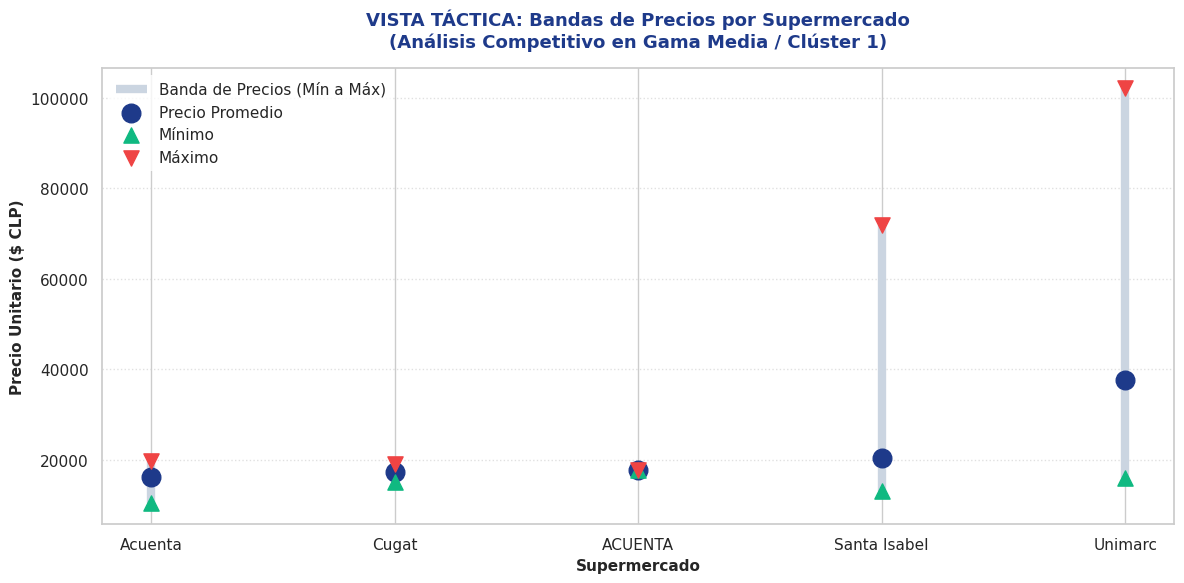

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conversión a Pandas únicamente para graficar
df_tac_pandas = kpi_tactico.toPandas()

# 2. Diseño del Gráfico Táctico Reformulado (Bandas de Precios de Competencia)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Dibujamos las líneas de rango (Mínimo a Máximo)
plt.vlines(
    x=df_tac_pandas['supermercado'], 
    ymin=df_tac_pandas['Precio_Minimo'], 
    ymax=df_tac_pandas['Precio_Maximo'], 
    colors='#cbd5e1', 
    linewidth=6, 
    label="Banda de Precios (Mín a Máx)"
)

# Añadimos puntos clave de posicionamiento
plt.scatter(df_tac_pandas['supermercado'], df_tac_pandas['Precio_Promedio_Gama_Media'], color='#1e3a8a', s=180, zorder=3, label="Precio Promedio")
plt.scatter(df_tac_pandas['supermercado'], df_tac_pandas['Precio_Minimo'], color='#10b981', marker='^', s=120, zorder=3, label="Mínimo")
plt.scatter(df_tac_pandas['supermercado'], df_tac_pandas['Precio_Maximo'], color='#ef4444', marker='v', s=120, zorder=3, label="Máximo")

# Personalización profesional
plt.title(
    "VISTA TÁCTICA: Bandas de Precios por Supermercado\n"
    "(Análisis Competitivo en Gama Media / Clúster 1)", 
    fontsize=13, 
    fontweight='bold', 
    pad=15, 
    color='#1e3a8a'
)
plt.ylabel("Precio Unitario ($ CLP)", fontsize=11, fontweight='bold')
plt.xlabel("Supermercado", fontsize=11, fontweight='bold')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
import pyspark.sql.functions as F

# 1. Definimos el umbral operativo crítico para el segmento económico
umbral_desvio_operacional = 15.0

# 2. Filtramos productos del Clúster 0 (Gama Económica) con un sobreprecio mayor al umbral (%)
kpi_operacional_alertas = df_historico.filter(
    (F.col("prediction") == 0) & 
    (F.col("dif_porcentual_promedio") >= umbral_desvio_operacional)
).select(
    "nombre_producto",
    "marca", 
    "supermercado", 
    "precio", 
    "precio_promedio_cat", 
    "dif_porcentual_promedio"
).orderBy(F.desc("dif_porcentual_promedio"))

# 3. Conteo de alertas detectadas para el reporte operacional
total_alertas = kpi_operacional_alertas.count()

# 4. Despliegue formal del KPI Operacional en consola
print("=========================================================================")
print(f"[KPI OPERACIONAL] - ALERTAS CRÍTICAS EN PRODUCTOS ECONÓMICOS (CLÚSTER 0)")
print(f"Foco: Variaciones sobre el promedio superiores al +{umbral_desvio_operacional}%")
print(f"Total de Alertas Detectadas: {total_alertas}")
print("=========================================================================")

# Mostramos las alertas prioritarias que el supervisor debe auditar en góndola
kpi_operacional_alertas.show(15, truncate=False)

[KPI OPERACIONAL] - ALERTAS CRÍTICAS EN PRODUCTOS ECONÓMICOS (CLÚSTER 0)
Foco: Variaciones sobre el promedio superiores al +15.0%
Total de Alertas Detectadas: 1166
+--------------------------------------------------+------------+------------+-------+-------------------+-----------------------+
|nombre_producto                                   |marca       |supermercado|precio |precio_promedio_cat|dif_porcentual_promedio|
+--------------------------------------------------+------------+------------+-------+-------------------+-----------------------+
|Duraznos en Mitades Drenado 1800 g - Neto 3000 ...|NETO        |Acuenta     |9590.0 |1944.0740740740741 |393.29                 |
|Duraznos en Cubitos en Almíbar Tarro Drenado 18...|GENÉRICA    |Acuenta     |9590.0 |1944.0740740740741 |393.29                 |
|Suavizante Líquido Classic Botella 5 L Soft...    |GENÉRICA    |Acuenta     |9490.0 |1944.0740740740741 |388.15                 |
|Harina Sin Polvos de Hornear 10 kg               

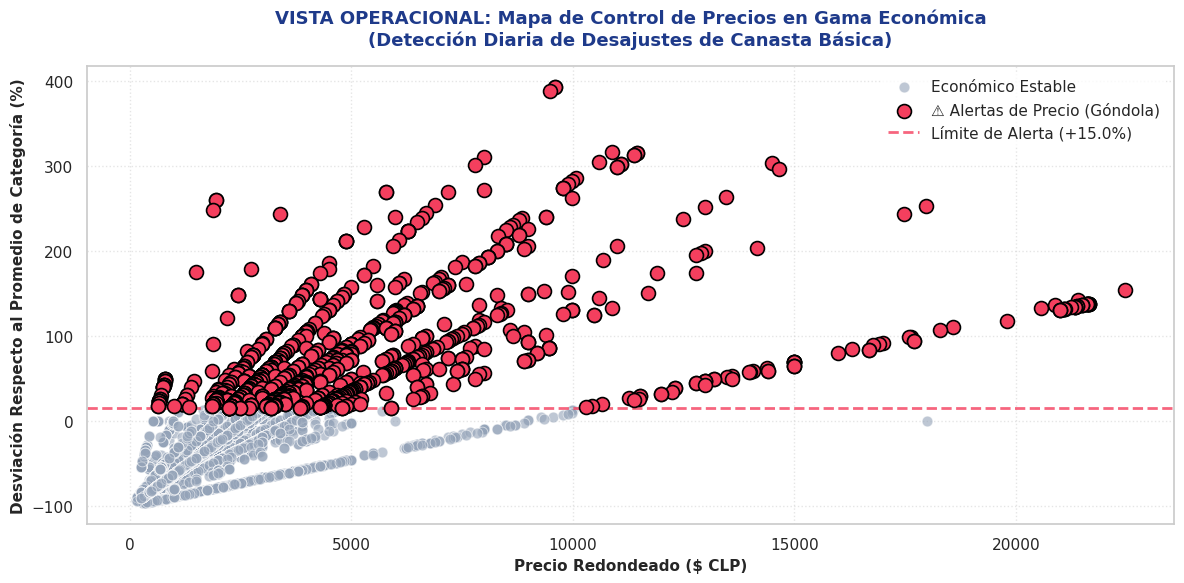

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conversión a DataFrames de Pandas para graficar con Seaborn de forma segura
df_op_pandas = df_historico.filter(F.col("prediction") == 0).toPandas()
df_alertas_pandas = kpi_operacional_alertas.toPandas()

# 2. Configuración del diseño del Gráfico Operacional
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Graficamos los productos del segmento económico estables en color gris neutro
sns.scatterplot(
    x="precio",
    y="dif_porcentual_promedio",
    data=df_op_pandas,
    color="#94a3b8",
    alpha=0.6,
    s=60,
    label="Económico Estable"
)

# Resaltamos en color carmesí los desvíos críticos que necesitan verificación
if not df_alertas_pandas.empty:
    sns.scatterplot(
        x="precio",
        y="dif_porcentual_promedio",
        data=df_alertas_pandas,
        color="#f43f5e",
        s=100,
        edgecolor="black",
        linewidth=1.2,
        zorder=4,
        label="⚠️ Alertas de Precio (Góndola)"
    )

# Línea del umbral operativo crítico establecido (15%)
plt.axhline(
    y=umbral_desvio_operacional, 
    color='#f43f5e', 
    linestyle='--', 
    alpha=0.8, 
    linewidth=2, 
    label=f"Límite de Alerta (+{umbral_desvio_operacional}%)"
)

# Títulos y personalización adaptada al Supervisor de Góndola
plt.title(
    "VISTA OPERACIONAL: Mapa de Control de Precios en Gama Económica\n"
    "(Detección Diaria de Desajustes de Canasta Básica)", 
    fontsize=13, 
    fontweight='bold', 
    pad=15, 
    color='#1e3a8a'
)
plt.xlabel("Precio Redondeado ($ CLP)", fontsize=11, fontweight='bold')
plt.ylabel("Desviación Respecto al Promedio de Categoría (%)", fontsize=11, fontweight='bold')
plt.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none')
plt.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
# 1. Seleccionamos las columnas clave del modelo de retail alimenticio para el Dashboard
columnas_dashboard = [
    "nombre_producto", "marca", "supermercado", "categoria", 
    "precio", "precio_promedio_cat", "dif_porcentual_promedio", "prediction"
]

df_dashboard_spark = df_historico.select(columnas_dashboard)

# 2. CORRECCIÓN: Forzamos la ruta absoluta hacia la carpeta 'notebooks'
# Esto garantiza que se cree ahí sin importar en qué carpeta estés ejecutando este notebook
ruta_salida_csv = "/home/jovyan/work/notebooks/datos_retail_dashboard.csv"

# Convertimos a Pandas y exportamos
df_dashboard_spark.toPandas().to_csv(ruta_salida_csv, index=False)

print("=========================================================================")
print("✅ ¡ÉXITO: Datos de la Canasta Básica exportados en la ruta correcta!")
print(f"Archivo generado directamente en: '{ruta_salida_csv}'")
print("=========================================================================")

✅ ¡ÉXITO: Datos de la Canasta Básica exportados en la ruta correcta!
Archivo generado directamente en: '/home/jovyan/work/notebooks/datos_retail_dashboard.csv'
